Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Instagram_fake_profile_dataset.csv")
df.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


In [3]:
df.shape

(5000, 12)

In [5]:
df.columns

Index(['profile pic', 'nums/length username', 'fullname words',
       'nums/length fullname', 'name==username', 'description length',
       'external URL', 'private', '#posts', '#followers', '#follows', 'fake'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
profile pic,0
nums/length username,0
fullname words,0
nums/length fullname,0
name==username,0
description length,0
external URL,0
private,0
#posts,0
#followers,0


In [7]:
df['fake'].value_counts()

,count
fake,
0,2500
1,2500


In [8]:
df.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.00000
mean,0.598200,0.166175,1.212800,0.036068,0.007600,20.997200,0.049600,0.227800,103.331400,5.124435e+04,481.381800,0.50000
std,0.490311,0.194733,0.890435,0.106235,0.086855,33.234706,0.217139,0.419455,377.804886,5.963749e+05,761.530132,0.50005
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.00000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+01,58.000000,0.00000
50%,1.000000,0.089193,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,10.000000,1.450000e+02,242.000000,0.50000
75%,1.000000,0.300410,2.000000,0.000000,0.000000,31.250000,0.000000,0.000000,81.000000,6.960000e+02,591.000000,1.00000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.00000


Correlation Heatmap

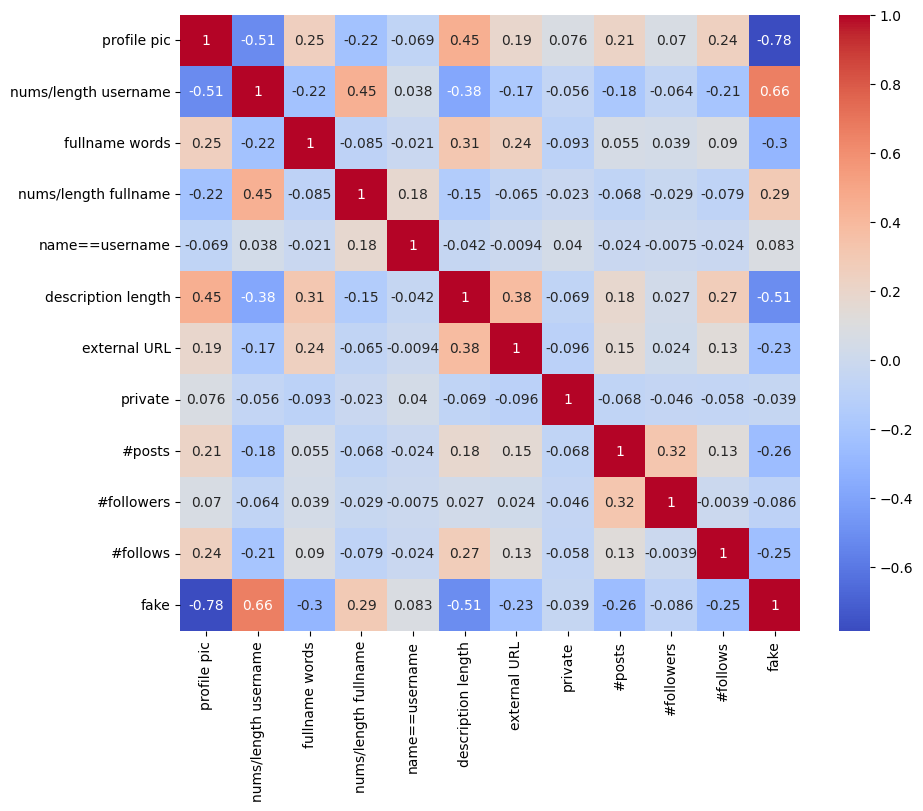

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Feature Engineering

In [10]:
#Create Follower–Following Ratio
df['follower_following_ratio'] = df['#followers'] / (df['#follows'] + 1)

In [11]:
#Create Posts per Follower
df['posts_per_follower'] = df['#posts'] / (df['#followers'] + 1)

In [12]:
#Create Profile Completeness Score
df['has_description'] = (df['description length'] > 0).astype(int)
df['has_fullname'] = (df['fullname words'] > 0).astype(int)

df['profile_completeness'] = df['profile pic'] + df['has_description'] + df['has_fullname']

In [13]:
df.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake,follower_following_ratio,posts_per_follower,has_description,has_fullname,profile_completeness
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0,1.046025,0.031968,1,0,2
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0,5.131086,0.104341,1,1,3
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0,1.606061,0.081250,0,1,2
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0,0.634969,1.636145,1,1,3
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0,1.188976,0.039474,0,1,2


Correlation Heatmap

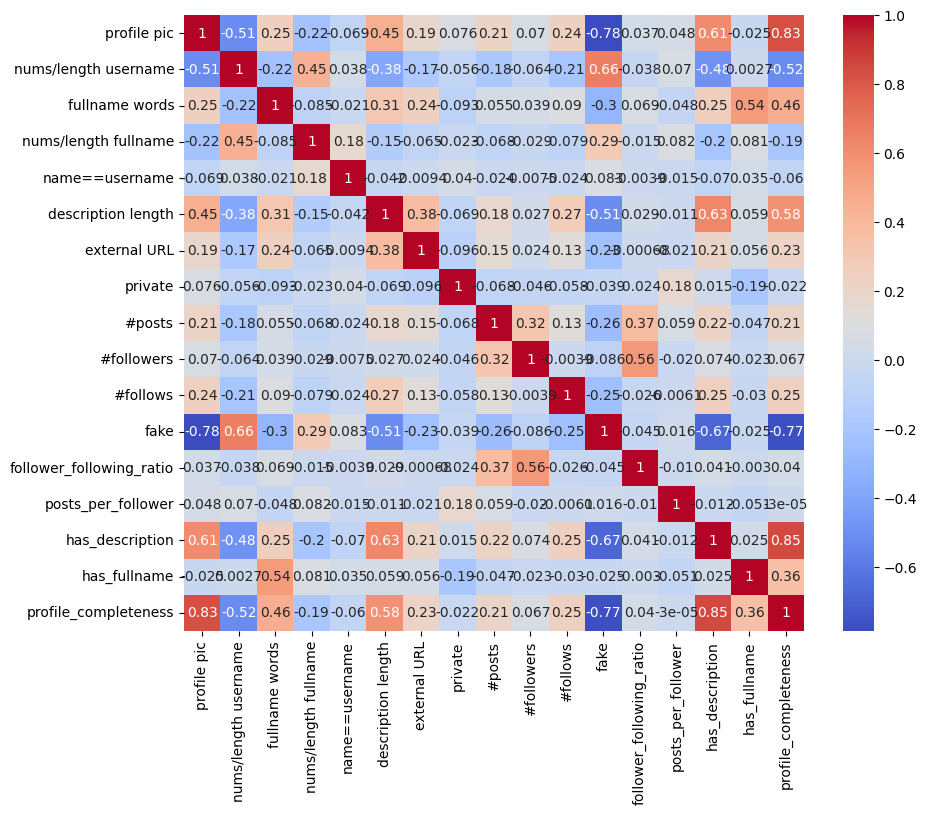

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Model Training

In [15]:
X = df.drop("fake", axis=1)
y = df["fake"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [20]:
y_pred = lr_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.962

In [23]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[484,  14],
       [ 24, 478]])

Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
rf_pred = rf_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, rf_pred)

0.986

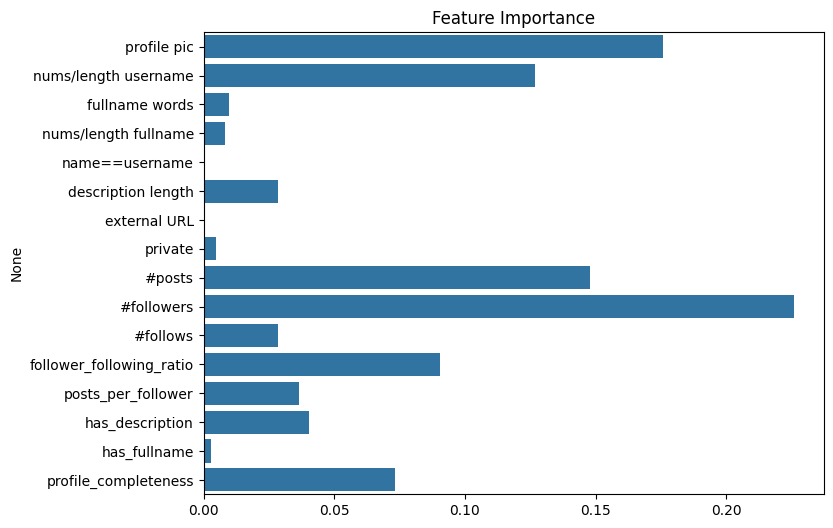

In [37]:
importances = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=features)

plt.title("Feature Importance")
plt.show()

XGBoost

In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:47:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
xgb_pred = xgb_model.predict(X_test)

In [29]:
accuracy_score(y_test, xgb_pred)

0.989

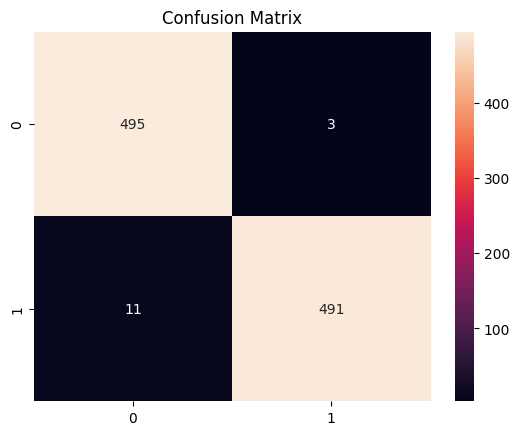

In [34]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

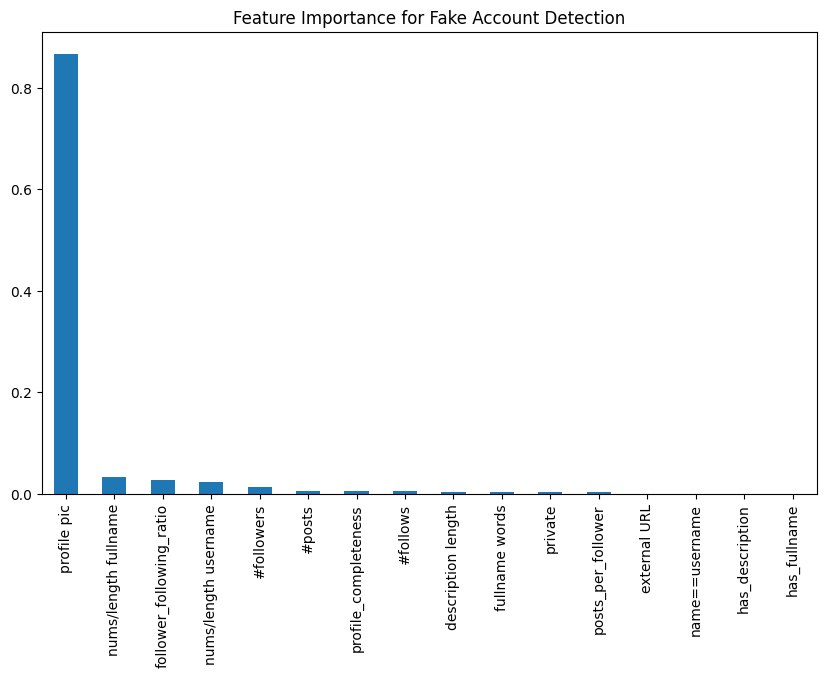

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

importance = xgb_model.feature_importances_
features = X.columns

feature_importance = pd.Series(importance, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')
plt.title("Feature Importance for Fake Account Detection")
plt.show()

In [31]:
import joblib

joblib.dump(xgb_model, "fake_account_detector.pkl")

['fake_account_detector.pkl']

In [32]:
import joblib

model = joblib.load("fake_account_detector.pkl")

In [33]:
def detect_fake_account(profile_pic, username_numbers, bio_present, posts, followers, follows):

    nums_username = 0.7 if username_numbers == 1 else 0
    fullname_words = 1
    nums_fullname = 0
    name_username = 0
    description_length = 1 if bio_present == 1 else 0
    external_url = 0
    private = 0

    follower_following_ratio = followers / (follows + 1)
    posts_per_follower = posts / (followers + 1)

    has_description = description_length
    has_fullname = 1

    profile_completeness = profile_pic + has_description + has_fullname

    features = [[
        profile_pic,
        nums_username,
        fullname_words,
        nums_fullname,
        name_username,
        description_length,
        external_url,
        private,
        posts,
        followers,
        follows,
        follower_following_ratio,
        posts_per_follower,
        has_description,
        has_fullname,
        profile_completeness
    ]]

    prob = model.predict_proba(features)[0][1]

    if prob > 0.8:
        risk = "High Risk (Likely Fake)"
    elif prob > 0.5:
        risk = "Medium Risk (Suspicious)"
    else:
        risk = "Low Risk (Likely Genuine)"

    return prob, risk

In [35]:
print("Instagram Fake Account Detection")

profile_pic = int(input("Profile picture present? (1 = Yes, 0 = No): "))
username_numbers = int(input("Username contains many numbers? (1 = Yes, 0 = No): "))
bio_present = int(input("Bio present? (1 = Yes, 0 = No): "))
posts = int(input("Number of posts: "))
followers = int(input("Number of followers: "))
follows = int(input("Number of following: "))

prob, risk = detect_fake_account(
    profile_pic,
    username_numbers,
    bio_present,
    posts,
    followers,
    follows
)

print("\nFake Account Probability:", round(prob, 3))
print("Risk Level:", risk)

Instagram Fake Account Detection
Profile picture present? (1 = Yes, 0 = No): 0
Username contains many numbers? (1 = Yes, 0 = No): 1
Bio present? (1 = Yes, 0 = No): 1
Number of posts: 0
Number of followers: 5
Number of following: 345

Fake Account Probability: 1.0
Risk Level: High Risk (Likely Fake)


In [34]:
from google.colab import files
files.download("fake_account_detector.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>